# 6 - Individual Variability

This notebook analyzes individual differences in ESM response patterns and label variability.

## Import libraries and define paths

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

%matplotlib inline

np.random.seed(42)

# ── Paths & style ─────────────────────────────────────────────────────────────────────────────
from utils import get_data_root, COLORS, WAVE_KEYS, WAVE_TO_DIR, set_paper_style

DATA_ROOT = get_data_root()
set_paper_style()


## Load data

In [14]:
# ── Data loading helpers ─────────────────────────────────────────────────────────────────────────────
from utils import (
    load_wave_esm_userinfo,
    normalize_label_series,
    SHARED_LABELS,
    load_df_X_combined, apply_28d_window,
)

# ── Combined sensor data ───────────────────────────────────────────────────────────────────────────────────────
df_X_combined = load_df_X_combined(DATA_ROOT)
df_X_28d, df_X_28d_stats = apply_28d_window(
    df_X_combined,
    dataset_col="META#dataset",
    pid_col="PIF#participantID",
    ts_col="PIF#timestamp",
    dataset_order=WAVE_KEYS,
)
if not df_X_28d.empty:
    _meta_cols_s6 = {"META#dataset", "PIF#participantID", "PIF#stress_label",
                     "PIF#time_offset", "PIF#timestamp", "__src"}
    numeric_common_s6 = [
        c for c in (set(df_X_28d.columns) - _meta_cols_s6)
        if df_X_28d[c].dtype in ["float64", "int64", "float32", "int32"]
    ]
else:
    numeric_common_s6 = []


## Data processing

In [3]:
esm_by_wave, _, esm_all = load_wave_esm_userinfo(
    WAVE_KEYS,
    DATA_ROOT,
    WAVE_TO_DIR,
    include_userinfo=False,
    include_study_day=True,
)

esm_all_28d, esm_28d_stats = apply_28d_window(
    esm_all,
    dataset_col="Wave",
    pid_col="Pcode",
    ts_col="ResponseTime",
    dataset_order=WAVE_KEYS,
)
esm_by_wave_28d = {
    k: esm_all_28d[esm_all_28d["Wave"] == k].copy() for k in WAVE_KEYS
}

## Visuals

### Caterpillar Plot: Stable Within-User Means (95% CI)

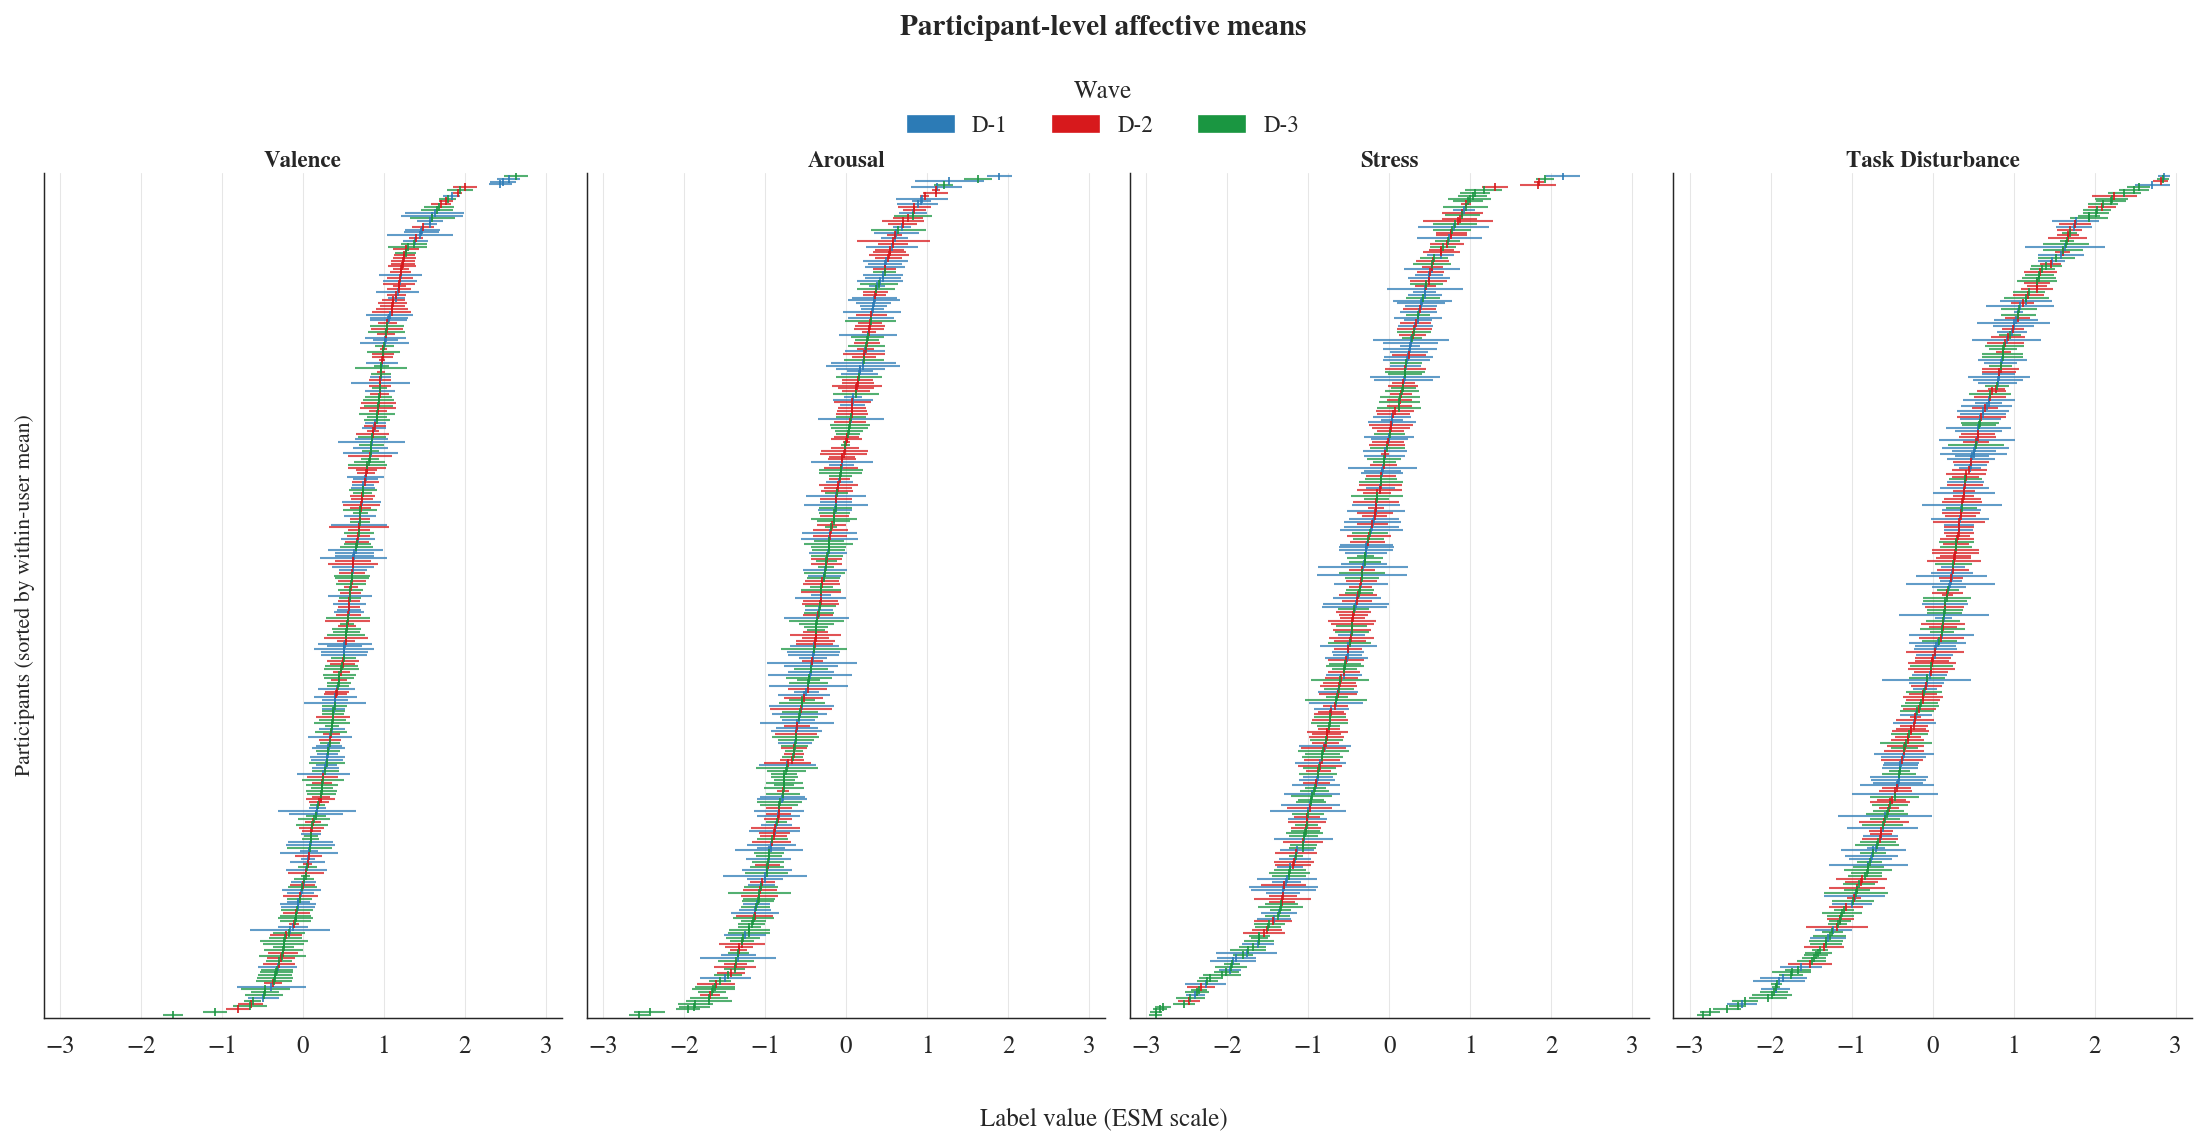

In [4]:
# ── Caterpillar plot: per-user mean ± 95% CI (pooled across waves) ─────────
_labels = ["Valence", "Arousal", "Stress", "Task Disturbance"]
_labels = [lbl for lbl in _labels if lbl in esm_all_28d.columns]

if esm_all_28d.empty or not _labels:
    print("Caterpillar plot skipped: missing ESM data or labels.")
else:
    _stats_parts = []
    for _lbl in _labels:
        _sub = esm_all_28d[["Wave", "Pcode", _lbl]].dropna()
        if _sub.empty:
            continue
        _agg = (
            _sub.groupby(["Wave", "Pcode"])[_lbl]
                .agg(["mean", "std", "count"])
                .reset_index()
                .rename(columns={"std": "sd", "count": "n"})
        )
        _agg["label"] = _lbl
        _stats_parts.append(_agg)

    if not _stats_parts:
        print("Caterpillar plot skipped: no label data after filtering.")
    else:
        _stats = pd.concat(_stats_parts, ignore_index=True)

        fig, axes = plt.subplots(1, 4, figsize=(14.8, 7.4), sharey=True)
        axes = np.array(axes).reshape(-1)
        _rng = np.random.RandomState(42)
        _xlim = (-3.2, 3.2)

        for idx, (ax, _lbl) in enumerate(zip(axes, ["Valence", "Arousal", "Stress", "Task Disturbance"])):
            if _lbl not in _stats["label"].unique():
                ax.set_visible(False)
                continue
            _df = _stats[_stats["label"] == _lbl].copy()
            _df = _df.sort_values("mean").reset_index(drop=True)
            _df["y"] = np.arange(len(_df))
            _df["y_plot"] = _df["y"] + _rng.uniform(-0.08, 0.08, size=len(_df))

            for _wk in WAVE_KEYS:
                _wk_df = _df[_df["Wave"] == _wk]
                if _wk_df.empty:
                    continue
                _mean = _wk_df["mean"].values
                _sd = _wk_df["sd"].fillna(0).values
                _n = _wk_df["n"].values
                _se = _sd / np.sqrt(_n)
                _lo = _mean - 1.96 * _se
                _hi = _mean + 1.96 * _se
                ax.hlines(_wk_df["y_plot"].values, _lo, _hi,
                          color=COLORS.get(_wk, "0.5"), alpha=0.75, lw=1.0, zorder=1)
                ax.scatter(_mean, _wk_df["y_plot"].values,
                           color=COLORS.get(_wk, "0.5"), s=12,
                           marker="|", linewidths=0.8, zorder=2)

            # _grand_mean = _df["mean"].mean()
            # ax.axvline(_grand_mean, color="0.5", ls="--", lw=0.6, zorder=1)

            ax.set_xlim(*_xlim)
            ax.set_xticks(np.arange(-3, 4, 1))
            ax.set_ylim(-1, len(_df))
            ax.set_yticks([])
            ax.set_title(_lbl, fontweight="bold", fontsize=11, pad=3)
            ax.grid(axis="x", color="0.9", lw=0.5, zorder=0)
            ax.spines[["top", "right"]].set_visible(False)
            ax.spines[["left", "bottom"]].set_linewidth(0.7)
            if idx == 0:
                ax.set_ylabel("Participants (sorted by within-user mean)", fontsize=10.5)
            ax.tick_params(axis="x", labelsize=12)

        _legend_handles = [
            mpatches.Patch(color=COLORS[w], label=w)
            for w in WAVE_KEYS if w in COLORS
        ]
        fig.legend(
            handles=_legend_handles, title="Wave", loc="upper center",
            ncol=len(_legend_handles), bbox_to_anchor=(0.5, 0.98),
            frameon=False, fontsize=11, title_fontsize=12
        )
        fig.suptitle(
            "Participant-level affective means",
            fontsize=14, fontweight="bold", y=1.02
        )
        fig.text(0.5, 0.02, "Label value (ESM scale)", ha="center", fontsize=12)
        plt.tight_layout(rect=[0, 0.06, 1, 0.96])
        plt.show()

---
### Individual Variability: Cross-User Shift Magnitude Within Each Wave (Helper)

In [5]:
# Cross-user shift magnitude decomposition within each wave
def variance_components(label: str) -> tuple[float, float, float]:
    if esm_all_28d.empty or label not in esm_all_28d.columns:
        return np.nan, np.nan, np.nan
    sub = esm_all_28d[["Wave", "Pcode", label]].dropna().copy()
    if sub.empty:
        return np.nan, np.nan, np.nan
    sub[label] = normalize_label_series(sub[label])
    grand_mean = sub[label].mean()
    total_var  = sub[label].var()
    if pd.isna(total_var) or total_var == 0:
        return np.nan, np.nan, np.nan
    wave_means = (
        sub.groupby("Wave")[label]
           .mean()
           .reset_index()
           .rename(columns={label: "wave_mean"})
    )
    person_means = (
        sub.groupby(["Wave", "Pcode"])[label]
           .mean()
           .reset_index()
           .rename(columns={label: "person_mean"})
    )
    sub = sub.merge(wave_means, on="Wave", how="left")
    sub = sub.merge(person_means, on=["Wave", "Pcode"], how="left")
    between_wave   = (sub["wave_mean"] - grand_mean).pow(2).mean()
    between_person = (sub["person_mean"] - sub["wave_mean"]).pow(2).mean()
    within_person  = max(0.0, total_var - between_wave - between_person)
    total = between_wave + between_person + within_person
    return within_person / total, between_person / total, between_wave / total

### Variance decomposition by person/day

This bar chart provides a direct cross-wave comparison of effect size or prevalence for the target metric.


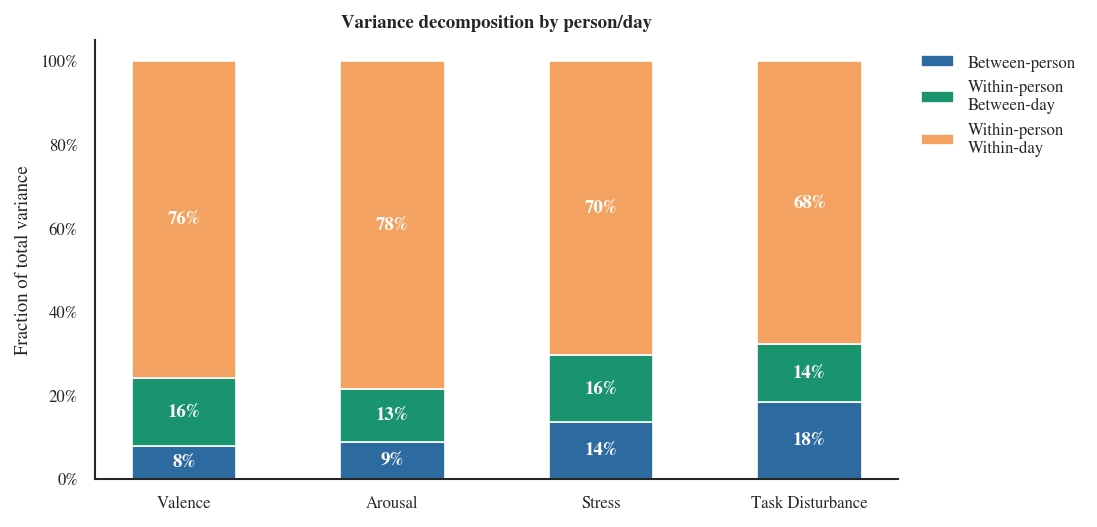

In [6]:
results = []

for label in SHARED_LABELS:
    if esm_all_28d.empty or label not in esm_all_28d.columns:
        continue
    df = esm_all_28d[["Pcode", "study_day", label]].dropna()

    grand_mean = df[label].mean()
    person_means = df.groupby("Pcode")[label].mean()

    # Between-person SS
    ss_between = sum(
        len(df[df["Pcode"] == p]) * (pm - grand_mean) ** 2
        for p, pm in person_means.items()
    )

    # Within-person between-day SS
    day_means = df.groupby(["Pcode", "study_day"])[label].mean().reset_index()
    day_means = day_means.merge(
        person_means.rename("pmean"), left_on="Pcode", right_index=True
    )
    ss_wpbd = (
        df.groupby(["Pcode", "study_day"])[label]
            .count()
            .reset_index(name="n")
            .merge(day_means, on=["Pcode", "study_day"])
    )
    ss_wpbd = (ss_wpbd["n"] * (ss_wpbd[label] - ss_wpbd["pmean"]) ** 2).sum()

    # Residual (within-person within-day)
    day_means_map = day_means.set_index(["Pcode", "study_day"])[label]
    df2 = df.copy()
    df2["day_mean"] = [day_means_map.get((r.Pcode, r.study_day), np.nan)
                        for _, r in df2.iterrows()]
    ss_resid = ((df2[label] - df2["day_mean"]) ** 2).sum()

    total = ss_between + ss_wpbd + ss_resid
    if total == 0:
        continue

    results.append({
        "label": label,
        "Between-person": ss_between / total,
        "Within-person\nBetween-day": ss_wpbd / total,
        "Within-person\nWithin-day": ss_resid / total,
    })

df_res = pd.DataFrame(results).set_index("label")
comp_colors = ["#2D6A9F", "#1A936F", "#F4A261"]

fig, ax = plt.subplots(figsize=(7.2, 3.4), constrained_layout=True)
bottom = np.zeros(len(df_res))
for col, color in zip(df_res.columns, comp_colors):
    vals = df_res[col].values
    bars = ax.bar(df_res.index, vals, bottom=bottom,
                    color=color, label=col, edgecolor="white", width=0.5)
    for bar, val, bot in zip(bars, vals, bottom):
        if val > 0.05:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bot + val / 2, f"{val:.0%}",
                    ha="center", va="center",
                    color="white", fontsize=9, fontweight="bold")
    bottom += vals

ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylabel("Fraction of total variance")
ax.set_title("Variance decomposition by person/day", fontweight="bold", fontsize=9)
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.show()

### Intra-Class Correlation per Label (all waves pooled)

This bar chart provides a direct cross-wave comparison of effect size or prevalence for the target metric.


### Variance Decomposition by Person/Day (Per Wave)

Same decomposition as above, shown separately for each wave.

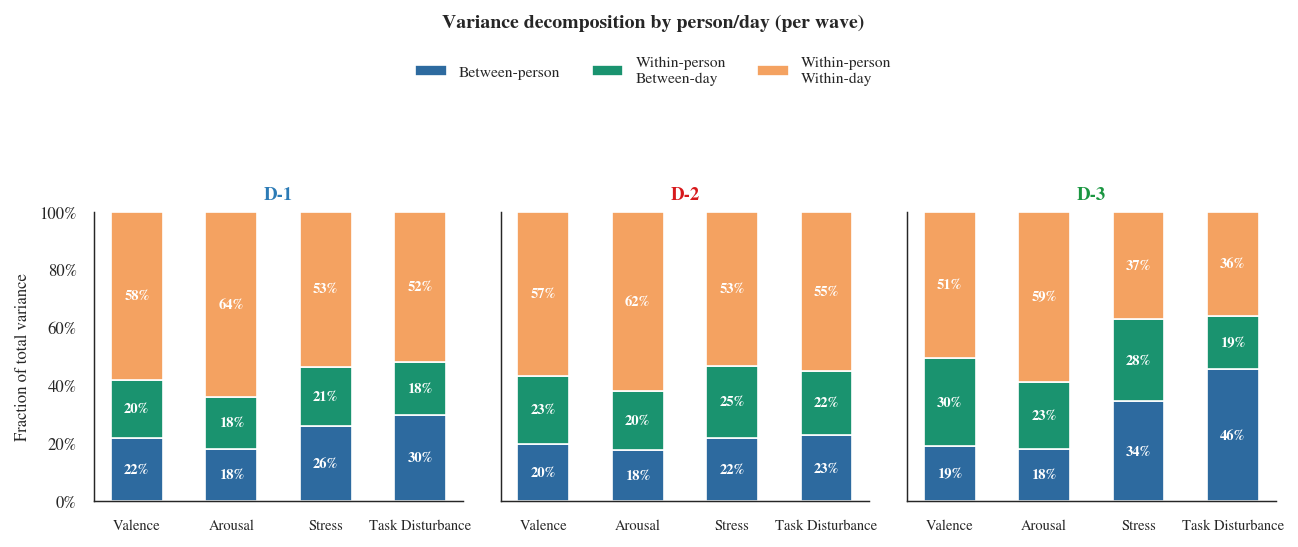

In [7]:
# ── Variance decomposition by person/day for each wave ───────────────────
def _variance_components_by_wave(df: pd.DataFrame, label: str) -> dict[str, float]:
    if df.empty or label not in df.columns:
        return {}
    sub = df[["Pcode", "study_day", label]].dropna()
    if sub.empty or sub["Pcode"].nunique() < 2:
        return {}
    grand_mean = sub[label].mean()
    person_means = sub.groupby("Pcode")[label].mean()

    ss_between = sum(
        len(sub[sub["Pcode"] == p]) * (pm - grand_mean) ** 2
        for p, pm in person_means.items()
    )

    day_means = sub.groupby(["Pcode", "study_day"])[label].mean().reset_index()
    day_means = day_means.merge(
        person_means.rename("pmean"), left_on="Pcode", right_index=True
    )
    ss_wpbd = (
        sub.groupby(["Pcode", "study_day"])[label]
           .count()
           .reset_index(name="n")
           .merge(day_means, on=["Pcode", "study_day"])
    )
    ss_wpbd = (ss_wpbd["n"] * (ss_wpbd[label] - ss_wpbd["pmean"]) ** 2).sum()

    day_means_map = day_means.set_index(["Pcode", "study_day"])[label]
    df2 = sub.copy()
    df2["day_mean"] = [day_means_map.get((r.Pcode, r.study_day), np.nan)
                        for _, r in df2.iterrows()]
    ss_resid = ((df2[label] - df2["day_mean"]) ** 2).sum()

    total = ss_between + ss_wpbd + ss_resid
    if total == 0:
        return {}
    return {
        "Between-person": ss_between / total,
        "Within-person\nBetween-day": ss_wpbd / total,
        "Within-person\nWithin-day": ss_resid / total,
    }

if esm_all_28d.empty or "study_day" not in esm_all_28d.columns:
    print("Variance by wave skipped: missing ESM data or study_day.")
else:
    _label_order = [lbl for lbl in SHARED_LABELS if lbl in esm_all_28d.columns]
    _wave_results = []
    for _wk in WAVE_KEYS:
        _wave_df = esm_all_28d[esm_all_28d["Wave"] == _wk]
        for _lbl in _label_order:
            _vals = _variance_components_by_wave(_wave_df, _lbl)
            if not _vals:
                continue
            _wave_results.append({"wave": _wk, "label": _lbl, **_vals})

    if not _wave_results:
        print("Variance by wave skipped: no valid label data.")
    else:
        df_wave = pd.DataFrame(_wave_results)
        comp_cols = ["Between-person", "Within-person\nBetween-day", "Within-person\nWithin-day"]
        comp_colors = ["#2D6A9F", "#1A936F", "#F4A261"]

        fig, axes = plt.subplots(1, 3, figsize=(8.8, 3.1), sharey=True)
        axes = np.array(axes).reshape(-1)

        for ax, _wk in zip(axes, WAVE_KEYS):
            _sub = df_wave[df_wave["wave"] == _wk]
            if _sub.empty:
                ax.set_visible(False)
                continue
            _sub = _sub.set_index("label").reindex(_label_order)
            bottom = np.zeros(len(_sub))
            for col, color in zip(comp_cols, comp_colors):
                vals = _sub[col].fillna(0).values
                bars = ax.bar(_sub.index, vals, bottom=bottom,
                              color=color, edgecolor="white", width=0.55, label=col)
                for bar, val, bot in zip(bars, vals, bottom):
                    if val > 0.05:
                        ax.text(bar.get_x() + bar.get_width() / 2,
                                bot + val / 2, f"{val:.0%}",
                                ha="center", va="center",
                                color="white", fontsize=7, fontweight="bold")
                bottom += vals

            ax.set_ylim(0, 1.0)
            ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
            ax.set_title(_wk, fontweight="bold", fontsize=9, color=COLORS.get(_wk, "black"))
            ax.tick_params(axis="x", labelsize=7, rotation=0)
            ax.spines[["top", "right"]].set_visible(False)
            ax.spines[["left", "bottom"]].set_linewidth(0.7)

        axes[0].set_ylabel("Fraction of total variance", fontsize=8)

        legend_handles = [
            mpatches.Patch(facecolor=c, edgecolor="white", label=lab)
            for lab, c in zip(comp_cols, comp_colors)
        ]
        fig.legend(
            handles=legend_handles, loc="upper center", ncol=3,
            bbox_to_anchor=(0.5, 1.10), frameon=False, fontsize=7.5
        )
        fig.suptitle(
            "Variance decomposition by person/day (per wave)",
            fontsize=9.5, fontweight="bold", y=1.16
        )
        plt.tight_layout(rect=[0, 0, 1, 0.92])
        plt.show()


### Representative Four-Week Stress Trajectories

This plot highlights representative user-level stress trajectories over the four-week window.


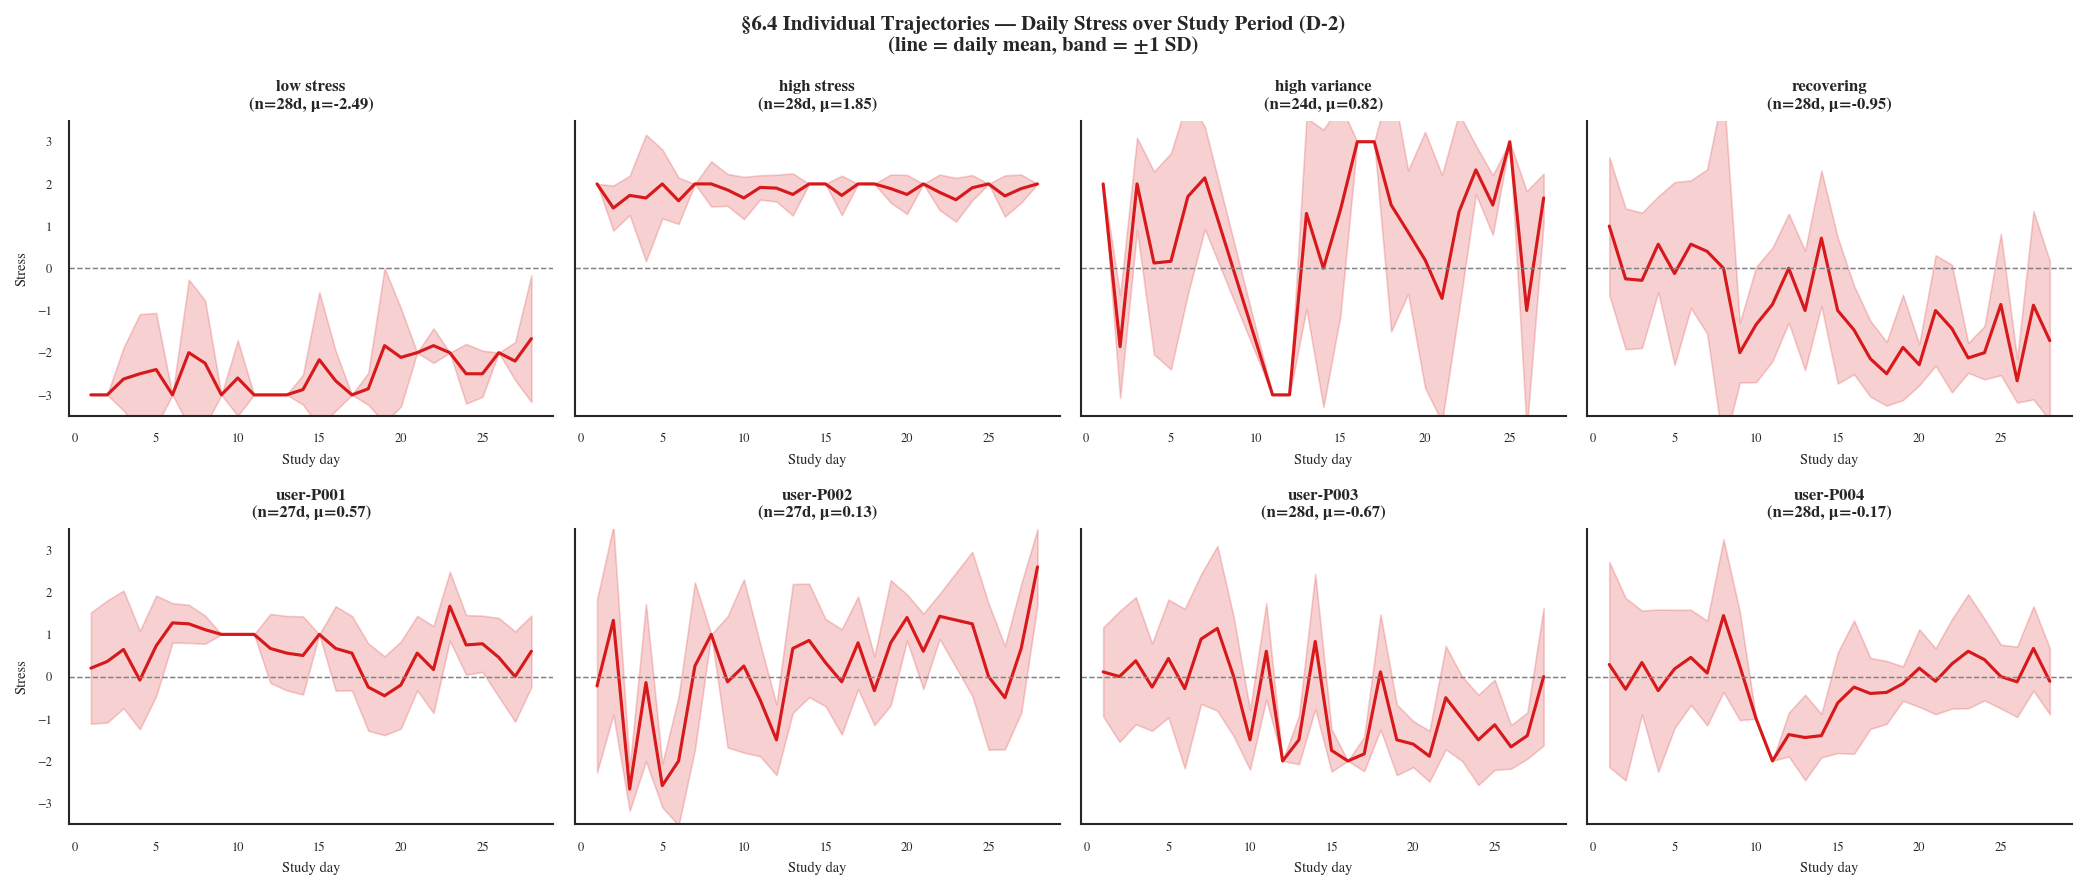

In [9]:
# ── Visual Q: Individual 4-week affective trajectories ───────────────────────
_stress_col_q = "Stress"

# Prefer longer-protocol waves (D-2, D-3) for 4-week data
# Use esm_all_28d (has study_day) filtered by wave rather than esm_by_wave_28d
_traj_waves = ["D-2", "D-3", "D-1"]
_traj_data = None
for _wk_q in _traj_waves:
    _df_q = esm_all_28d[esm_all_28d["Wave"] == _wk_q].copy()
    if _df_q.empty or _stress_col_q not in _df_q.columns or "study_day" not in _df_q.columns:
        continue
    _df_q[_stress_col_q] = normalize_label_series(_df_q[_stress_col_q])
    _traj_data = _df_q
    _traj_wave_key = _wk_q
    break

if _traj_data is not None:
    # Select users with ≥ 14 days of data
    _day_counts = _traj_data.groupby("Pcode")["study_day"].nunique()
    _eligible = _day_counts[_day_counts >= 14].index.tolist()
    _stats_q = _traj_data[_traj_data["Pcode"].isin(_eligible)].groupby("Pcode")[_stress_col_q].agg(
        ["mean", "std", "count"]
    )
    _stats_q = _stats_q[_stats_q["count"] >= 20]

    # Compute first-half vs second-half mean for "recovering" archetype
    def _recovery_score(pcode):
        _d = _traj_data[_traj_data["Pcode"] == pcode][["study_day", _stress_col_q]].dropna()
        _mid = _d["study_day"].median()
        _early = _d[_d["study_day"] <= _mid][_stress_col_q].mean()
        _late = _d[_d["study_day"] > _mid][_stress_col_q].mean()
        return _early - _late   # positive = decreasing stress (recovering)

    _candidates = {}
    _sorted_mean = _stats_q["mean"].sort_values()

    # Consistently low: bottom quartile of mean
    _low_q = _sorted_mean.quantile(0.25)
    _low_cands = _sorted_mean[_sorted_mean <= _low_q].index
    if len(_low_cands) > 0:
        _candidates["low stress"] = _low_cands[0]

    # Consistently high: top quartile
    _hi_q = _sorted_mean.quantile(0.75)
    _hi_cands = _sorted_mean[_sorted_mean >= _hi_q].index
    if len(_hi_cands) > 0:
        _candidates["high stress"] = _hi_cands[-1]

    # High variance
    _var_sorted = _stats_q["std"].sort_values(ascending=False)
    for _p in _var_sorted.index:
        if _p not in _candidates.values():
            _candidates["high variance"] = _p
            break

    # Recovering (high→low)
    _rec_scores = {p: _recovery_score(p) for p in _stats_q.index if p not in _candidates.values()}
    if _rec_scores:
        _best_rec = max(_rec_scores, key=_rec_scores.get)
        if _rec_scores[_best_rec] > 0.2:
            _candidates["recovering"] = _best_rec

    # Additional diverse users to fill up to 8 panels
    for _p in _stats_q.index:
        if len(_candidates) >= 8:
            break
        if _p not in _candidates.values():
            _candidates[f"user-{_p}"] = _p

    _n_panels = len(_candidates)
    if _n_panels == 0:
        print(f"Visual Q: no users with ≥ 14 days found in {_traj_wave_key}.")
    else:
        _ncols = 4
        _nrows = (_n_panels + _ncols - 1) // _ncols
        fig, axes = plt.subplots(_nrows, _ncols, figsize=(3.5 * _ncols, 3 * _nrows),
                                  sharey=True)
        axes = np.array(axes).flat

        _wave_color_q = COLORS.get(_traj_wave_key, "#555555")

        for ax, (archetype, pcode) in zip(axes, _candidates.items()):
            _user_df = _traj_data[_traj_data["Pcode"] == pcode].groupby("study_day")[_stress_col_q].agg(
                ["mean", "std"]
            )
            _days = _user_df.index.values
            _means = _user_df["mean"].values
            _stds = _user_df["std"].fillna(0).values
            ax.plot(_days, _means, color=_wave_color_q, lw=1.5)
            ax.fill_between(_days, _means - _stds, _means + _stds,
                            alpha=0.2, color=_wave_color_q)
            ax.axhline(0, color="grey", lw=0.7, ls="--")
            ax.set_ylim(-3.5, 3.5)
            ax.set_title(f"{archetype}\n(n={len(_days)}d, μ={_means.mean():.2f})",
                         fontsize=8, fontweight="bold")
            ax.set_xlabel("Study day", fontsize=7)
            if ax.get_subplotspec().colspan.start == 0:
                ax.set_ylabel("Stress", fontsize=7)
            ax.tick_params(labelsize=6)
            ax.spines[["top", "right"]].set_visible(False)

        # Hide unused axes
        for ax in axes[len(_candidates):]:
            ax.set_visible(False)

        fig.suptitle(f"§6.4 Individual Trajectories — Daily Stress over Study Period ({_traj_wave_key})\n"
                     "(line = daily mean, band = ±1 SD)", fontsize=10, fontweight="bold")
        plt.tight_layout()
        plt.show()
else:
    print("Skipped Visual Q: no ESM wave with study_day and Stress columns found.")


### Cross-User Shift Magnitude Within Each Wave

This 2×2 panel compares covariate, conditional, label, and concept shift magnitudes across waves.


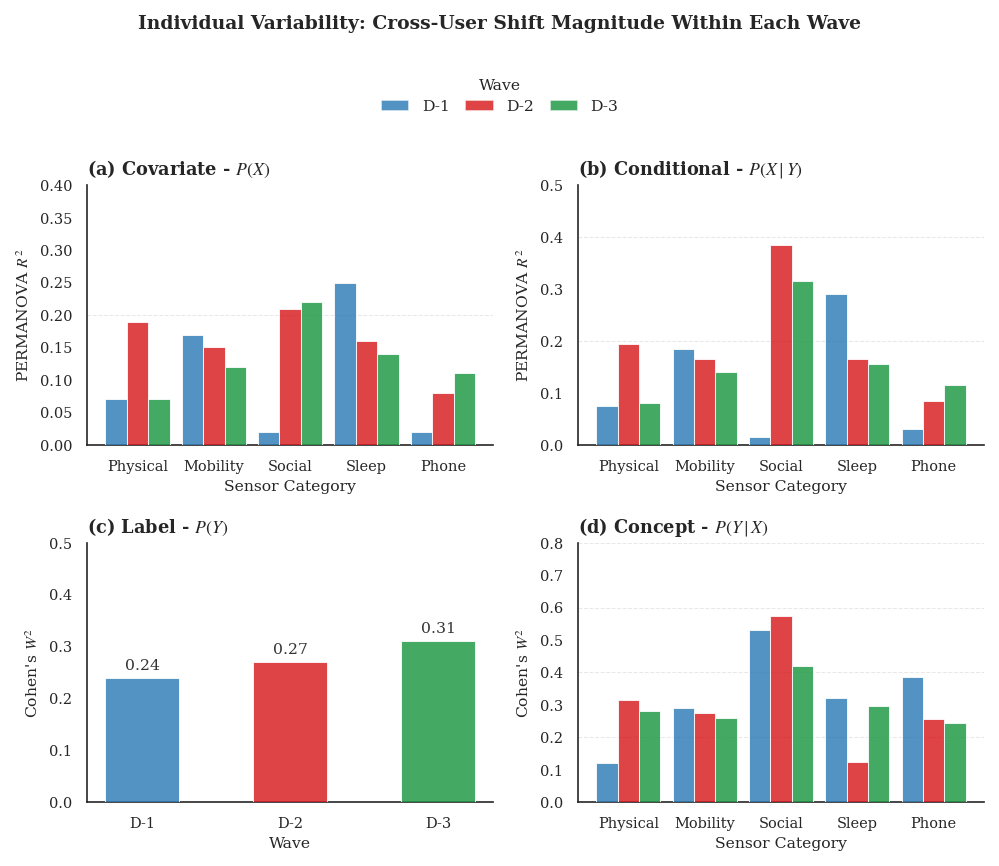

In [10]:
# ── NeurIPS rcParams ──────────────────────────────────────────────────────────
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
    "mathtext.fontset": "stix",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "axes.titlepad": 6,
    "axes.grid": False,
    "xtick.major.size": 3.5,
    "xtick.major.width": 0.7,
    "ytick.major.size": 3.5,
    "ytick.major.width": 0.7,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "legend.fontsize": 7.5,
    "legend.frameon": False,
    "figure.dpi": 150,
})

# Use notebook-level constants if available, else fall back.
_waves = WAVE_KEYS if "WAVE_KEYS" in globals() else ["D-1", "D-2", "D-3"]
_colors = COLORS if "COLORS" in globals() else {"D-1": "#2C7BB6", "D-2": "#D7191C", "D-3": "#1A9641"}
_cats = ["Physical", "Mobility", "Social", "Sleep", "Phone"]
_hatches = {"D-1": "", "D-2": "", "D-3": ""}

# ── Data: CrossShift Figure 6 and Table 4, D1/D2/D3 columns ──────────────────
covariate_r2 = {
    "Physical": {"D-1": 0.07,  "D-2": 0.19,  "D-3": 0.07},
    "Mobility": {"D-1": 0.17,  "D-2": 0.15,  "D-3": 0.12},
    "Social":   {"D-1": 0.02,  "D-2": 0.21,  "D-3": 0.22},
    "Sleep":    {"D-1": 0.25,  "D-2": 0.16,  "D-3": 0.14},
    "Phone":    {"D-1": 0.02,  "D-2": 0.08,  "D-3": 0.11},
}

conditional_r2 = {
    "Physical": {"D-1": 0.075, "D-2": 0.195, "D-3": 0.080},
    "Mobility": {"D-1": 0.185, "D-2": 0.165, "D-3": 0.140},
    "Social":   {"D-1": 0.015, "D-2": 0.385, "D-3": 0.315},
    "Sleep":    {"D-1": 0.290, "D-2": 0.165, "D-3": 0.155},
    "Phone":    {"D-1": 0.030, "D-2": 0.085, "D-3": 0.115},
}

label_w2 = {"D-1": 0.24, "D-2": 0.27, "D-3": 0.31}

concept_w2 = {
    "Physical": {"D-1": 0.120, "D-2": 0.315, "D-3": 0.280},
    "Mobility": {"D-1": 0.290, "D-2": 0.275, "D-3": 0.260},
    "Social":   {"D-1": 0.530, "D-2": 0.575, "D-3": 0.420},
    "Sleep":    {"D-1": 0.320, "D-2": 0.125, "D-3": 0.295},
    "Phone":    {"D-1": 0.385, "D-2": 0.255, "D-3": 0.245},
}

# ── Layout ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(6.75, 5.5))
fig.subplots_adjust(hspace=0.56, wspace=0.38)

ax_cov, ax_cond = axes[0, 0], axes[0, 1]
ax_lbl, ax_con = axes[1, 0], axes[1, 1]

bar_width = 0.28
x = np.arange(len(_cats))
x_lbl = np.arange(len(_waves))

# ── (a) Covariate: category bars ────────────────────────────────────────────
for w_idx, wk in enumerate(_waves):
    offset = (w_idx - 1) * bar_width
    vals = [covariate_r2[cat][wk] for cat in _cats]
    ax_cov.bar(
        x + offset, vals,
        width=bar_width, color=_colors[wk], hatch=_hatches[wk],
        alpha=0.82, edgecolor="white", linewidth=0.5, label=wk, zorder=3,
    )
for ref in np.arange(0.2, 0.40, 0.2):
    ax_cov.axhline(ref, color="#E8E8E8", lw=0.5, ls="--", zorder=1)
# ax_cov.axhline(mean_cov, color="#666666", lw=0.9, ls=":", zorder=2)
ax_cov.set_ylim(0, 0.40)
ax_cov.set_ylabel(r"PERMANOVA $R^2$", fontsize=7.5)
ax_cov.set_title(r"(a) Covariate - $P(X)$", fontsize=8.5, fontweight="bold", loc="left", pad=5)
ax_cov.set_xticks(x)
ax_cov.set_xticklabels(_cats, fontsize=7)
ax_cov.set_xlabel("Sensor Category", fontsize=7.5, labelpad=3)
ax_cov.tick_params(labelsize=7)
ax_cov.spines["left"].set_linewidth(0.8)

# ── (b) Conditional: category bars ──────────────────────────────────────────
for w_idx, wk in enumerate(_waves):
    offset = (w_idx - 1) * bar_width
    vals = [conditional_r2[cat][wk] for cat in _cats]
    ax_cond.bar(
        x + offset, vals,
        width=bar_width, color=_colors[wk], hatch=_hatches[wk],
        alpha=0.82, edgecolor="white", linewidth=0.5, label=wk, zorder=3,
    )
for ref in np.arange(0.2, 0.50, 0.2):
    ax_cond.axhline(ref, color="#E8E8E8", lw=0.5, ls="--", zorder=1)
ax_cond.set_ylim(0, 0.50)
ax_cond.set_ylabel(r"PERMANOVA $R^2$", fontsize=7.5)
ax_cond.set_title(r"(b) Conditional - $P(X \mid Y)$", fontsize=8.5, fontweight="bold", loc="left", pad=5)
ax_cond.set_xticks(x)
ax_cond.set_xticklabels(_cats, fontsize=7)
ax_cond.set_xlabel("Sensor Category", fontsize=7.5, labelpad=3)
ax_cond.tick_params(labelsize=7)
ax_cond.spines["left"].set_linewidth(0.8)

# ── (c) Label: wave-only bars ───────────────────────────────────────────────
for w_idx, wk in enumerate(_waves):
    ax_lbl.bar(
        x_lbl[w_idx], label_w2[wk],
        width=0.50, color=_colors[wk], hatch=_hatches[wk],
        alpha=0.82, edgecolor="white", linewidth=0.5, label=wk, zorder=3,
    )
    ax_lbl.text(
        x_lbl[w_idx], label_w2[wk] + 0.01, f"{label_w2[wk]:.2f}",
        ha="center", va="bottom", fontsize=7.5, color="#333333",
    )
ax_lbl.set_ylim(0, 0.50)
ax_lbl.set_ylabel(r"Cohen's $W^2$", fontsize=7.5)
ax_lbl.set_title(r"(c) Label - $P(Y)$", fontsize=8.5, fontweight="bold", loc="left", pad=5)
ax_lbl.set_xticks(x_lbl)
ax_lbl.set_xticklabels(_waves, fontsize=8)
ax_lbl.set_xlabel("Wave", fontsize=7.5, labelpad=3)
ax_lbl.tick_params(labelsize=7)
ax_lbl.spines["left"].set_linewidth(0.8)

# ── (d) Concept: category bars ──────────────────────────────────────────────
for w_idx, wk in enumerate(_waves):
    offset = (w_idx - 1) * bar_width
    vals = [concept_w2[cat][wk] for cat in _cats]
    ax_con.bar(
        x + offset, vals,
        width=bar_width, color=_colors[wk], hatch=_hatches[wk],
        alpha=0.82, edgecolor="white", linewidth=0.5, label=wk, zorder=3,
    )
for ref in np.arange(0.2, 0.80, 0.2):
    ax_con.axhline(ref, color="#E8E8E8", lw=0.5, ls="--", zorder=1)
ax_con.set_ylim(0, 0.80)
ax_con.set_ylabel(r"Cohen's $W^2$", fontsize=7.5)
ax_con.set_title(r"(d) Concept - $P(Y \mid X)$", fontsize=8.5, fontweight="bold", loc="left", pad=5)
ax_con.set_xticks(x)
ax_con.set_xticklabels(_cats, fontsize=7)
ax_con.set_xlabel("Sensor Category", fontsize=7.5, labelpad=3)
ax_con.tick_params(labelsize=7)
ax_con.spines["left"].set_linewidth(0.8)

# ── Shared legend + title ───────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(facecolor=_colors[w], hatch=_hatches[w], edgecolor="white", alpha=0.82, label=w)
    for w in _waves
]
fig.legend(
    handles=legend_handles,
    title="Wave",
    title_fontsize=7.5,
    fontsize=7.5,
    loc="upper center",
    ncol=len(_waves) + 1,
    bbox_to_anchor=(0.5, 1.04),
    frameon=False,
    handlelength=1.8,
    columnspacing=1.0,
)

fig.suptitle(
    "Individual Variability: Cross-User Shift Magnitude Within Each Wave",
    fontsize=9,
    fontweight="bold",
    y=1.10,
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

### Visual 3-Style: Daily Label Means (6 Users, Days 1-28)

Pooled across waves; labels are auto-scaled to 0-1 for visualization only.

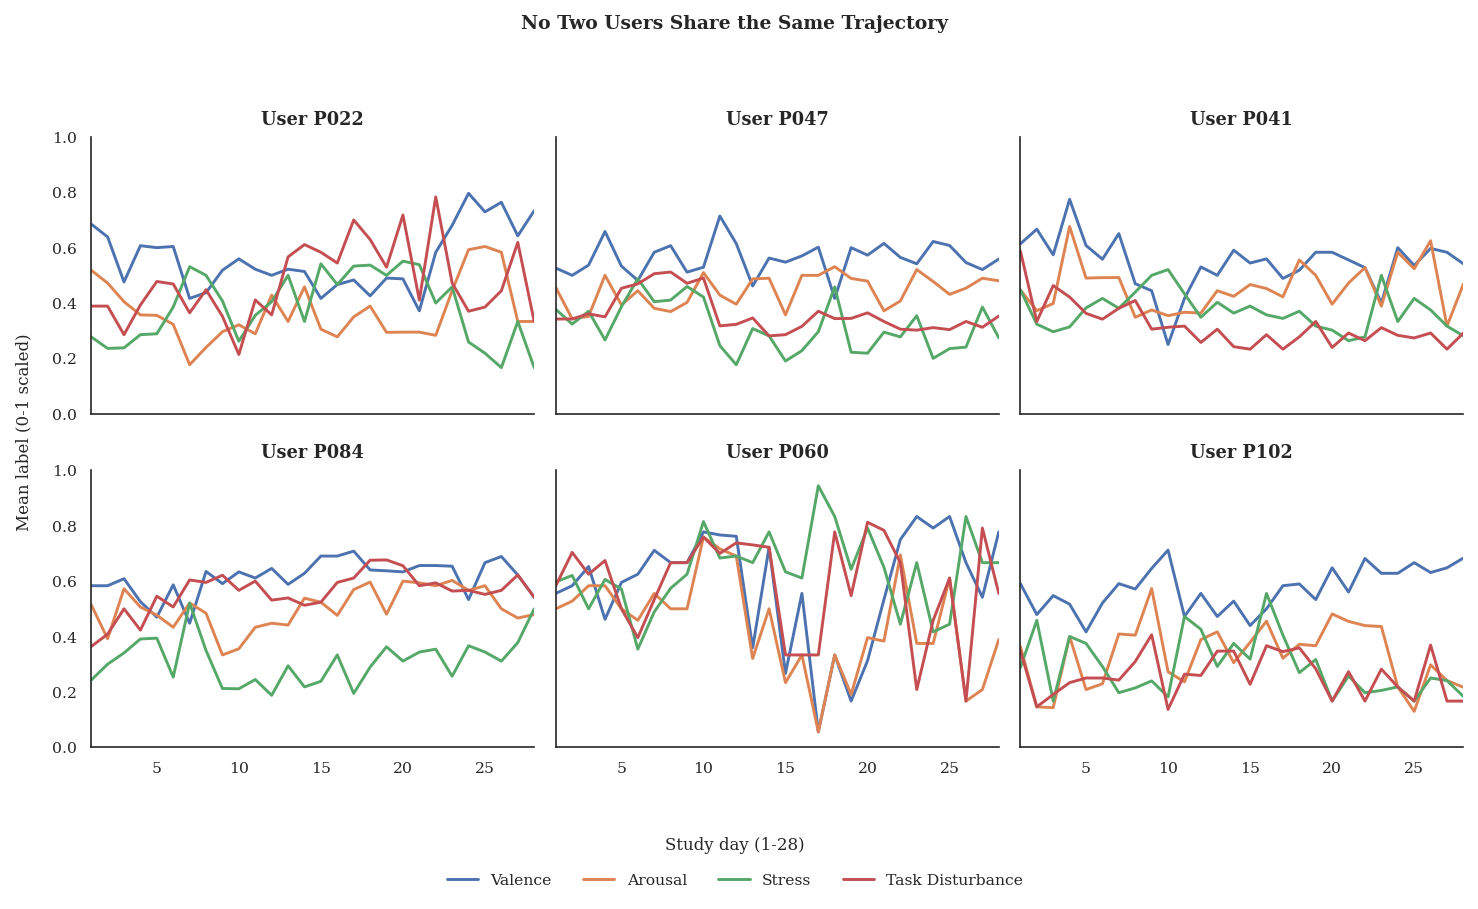

In [ ]:
# ── Visual 3-style: 6 users, daily label means (auto-scaled 0-1) ───────────
_days = np.arange(1, 29)
_labels = [lbl for lbl in SHARED_LABELS if lbl in esm_all_28d.columns]

if esm_all_28d.empty or not _labels or "study_day" not in esm_all_28d.columns:
    print("Visual 3-style skipped: missing ESM data, labels, or study_day.")
else:
    _df = esm_all_28d[["Pcode", "study_day"] + _labels].dropna(subset=["Pcode", "study_day"]).copy()
    _df = _df[_df["study_day"].between(1, 28)]

    # Auto-detect label scale and map to 0-1 (for visualization only)
    _scaled = _df.copy()
    for _lbl in _labels:
        _vals = _scaled[_lbl].dropna()
        if _vals.empty:
            continue
        _min, _max = _vals.min(), _vals.max()
        if _min < 0:
            _scaled[_lbl] = (_scaled[_lbl] + 3) / 6.0
        else:
            _scaled[_lbl] = _scaled[_lbl] / 6.0

    # Per-user, per-day mean for each label
    _daily = _scaled.groupby(["Pcode", "study_day"], as_index=False)[_labels].mean()

    # Users with complete coverage for days 1-28
    _day_counts = _daily.groupby("Pcode")["study_day"].nunique()
    _eligible = _day_counts[_day_counts == 28].index

    if len(_eligible) < 6:
        print(f"Visual 3-style skipped: only {len(_eligible)} users with full 28-day coverage.")
    else:
        np.random.seed(42)
        _picked_users = np.random.choice(_eligible, size=6, replace=False)

        _ncols, _nrows = 3, 2
        fig, axes = plt.subplots(_nrows, _ncols, figsize=(10.0, 5.8), sharex=True, sharey=True)
        axes = np.array(axes).reshape(-1)

        for ax, pcode in zip(axes, _picked_users):
            _u = _daily[_daily["Pcode"] == pcode]
            _u = _u.set_index("study_day").reindex(_days)
            for _lbl in _labels:
                ax.plot(_days, _u[_lbl].values, lw=1.4, label=_lbl)
            ax.set_title(f"User {pcode}", fontsize=8.5, fontweight="bold")
            ax.set_xlim(1, 28)
            ax.set_ylim(0, 1)

        for ax in axes[len(_picked_users):]:
            ax.set_visible(False)

        fig.text(0.5, 0.02, "Study day (1-28)", ha="center", fontsize=8)
        fig.text(0.02, 0.5, "Mean label (0-1 scaled)", va="center", rotation="vertical", fontsize=8)
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="lower center",bbox_to_anchor=(0.5, -0.04), ncol=len(_labels), frameon=False, fontsize=7.5)
        fig.suptitle("Trajectory of mean daily labels for 6 users",
                     fontsize=9, fontweight="bold", y=0.98)
        plt.tight_layout(rect=[0.03, 0.08, 1, 0.94])
        plt.show()
